In [5]:
import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv(
    r"C:\Project 5 (Citi Bike Project)\2.1_Advanced_Clean_data.csv"
)
df.head(5)

,Unnamed: 0,Trip_Duration,Start_Time,Stop_Time,Start_Station_Id,Start_Station_Name,Start_Station_Latitude,Start_Station_Longitude,End_Station_Id,End_Station_Name,...,Precipitation (Mm),Wind_Speed_10M (Km/H),Wind_Direction_10M (°),Weather_Code (Wmo Code),Start_Hour,Day_of_Week,Day_Type,Month,Peak_Hour,Season
0,0,471,2014-01-01 00:00:06,2014-01-01 00:07:57,2009,Catherine St & Monroe St,40.711174,-73.996826,263,Elizabeth St & Hester St,...,0.0,15.0,281,0,0,Wednesday,Weekday,1,False,Winter
1,1,1494,2014-01-01 00:00:38,2014-01-01 00:25:32,536,1 Ave & E 30 St,40.741444,-73.975361,259,South St & Whitehall St,...,0.0,15.0,281,0,0,Wednesday,Weekday,1,False,Winter
2,2,464,2014-01-01 00:03:59,2014-01-01 00:11:43,228,E 48 St & 3 Ave,40.754601,-73.971879,2022,E 59 St & Sutton Pl,...,0.0,15.0,281,0,0,Wednesday,Weekday,1,False,Winter
3,3,373,2014-01-01 00:05:15,2014-01-01 00:11:28,519,Pershing Square N,40.751884,-73.977702,526,E 33 St & 5 Ave,...,0.0,15.0,281,0,0,Wednesday,Weekday,1,False,Winter
4,4,660,2014-01-01 00:05:18,2014-01-01 00:16:18,83,Atlantic Ave & Fort Greene Pl,40.683826,-73.976323,436,Hancock St & Bedford Ave,...,0.0,15.0,281,0,0,Wednesday,Weekday,1,False,Winter


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 964253 entries, 0 to 964252
Data columns (total 31 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                964253 non-null  int64  
 1   Trip_Duration             964253 non-null  int64  
 2   Start_Time                964253 non-null  str    
 3   Stop_Time                 964253 non-null  str    
 4   Start_Station_Id          964253 non-null  int64  
 5   Start_Station_Name        964253 non-null  str    
 6   Start_Station_Latitude    964253 non-null  float64
 7   Start_Station_Longitude   964253 non-null  float64
 8   End_Station_Id            964253 non-null  int64  
 9   End_Station_Name          964253 non-null  str    
 10  End_Station_Latitude      964253 non-null  float64
 11  End_Station_Longitude     964253 non-null  float64
 12  Bike_Id                   964253 non-null  int64  
 13  User_Type                 964253 non-null  str    
 14 

# Distribution of Trip Duration

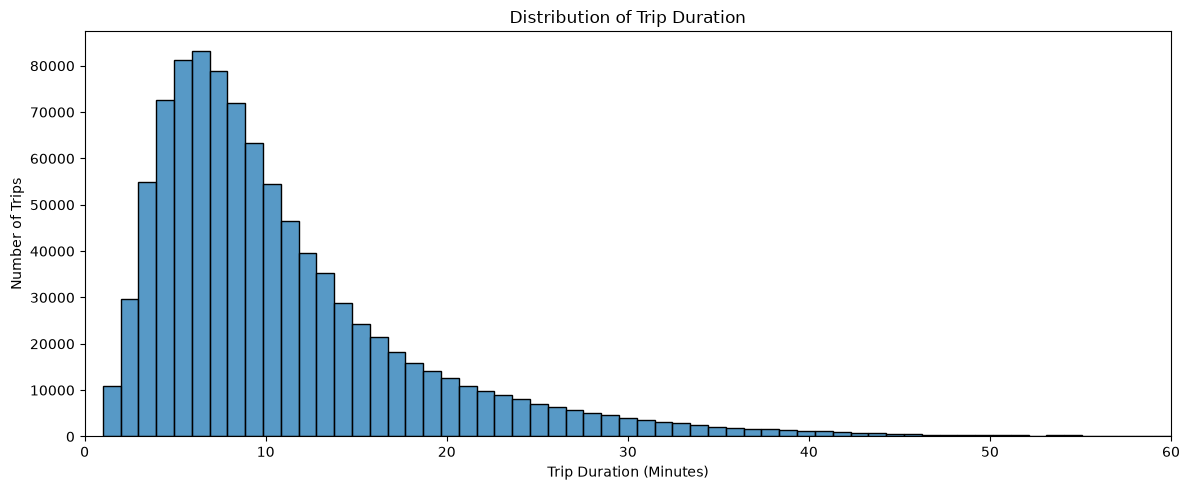

In [8]:
# Histogram of Trip durations

trip_duration = df.loc[
    df["Trip_Duration_Minutes"].between(0, 60),
    "Trip_Duration_Minutes"
]

plt.figure(figsize=(12, 5))

sns.histplot(
    trip_duration,
    bins=60
)

plt.title("Distribution of Trip Duration")
plt.xlabel("Trip Duration (Minutes)")
plt.ylabel("Number of Trips")
plt.xlim(0, 60)

plt.tight_layout()
plt.show()

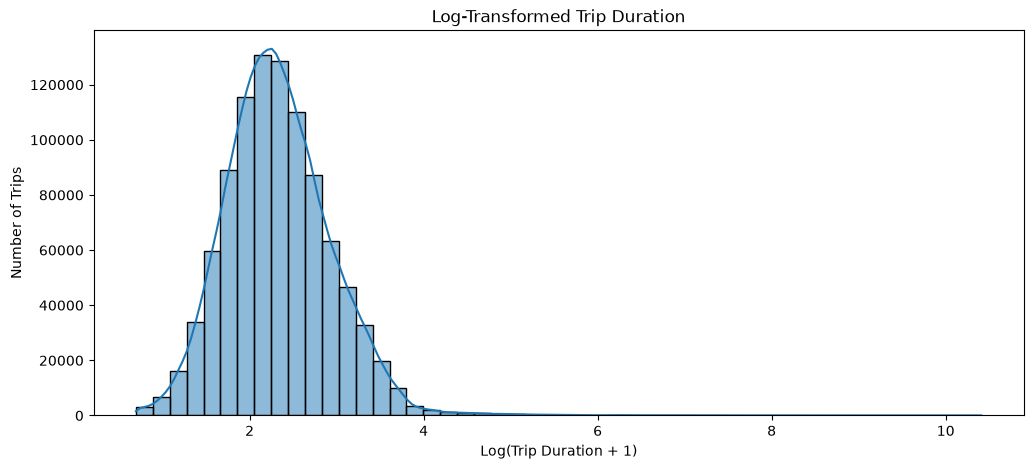

In [9]:
# Log-Transformed Trip Duration

plt.figure(figsize=(12, 5))

sns.histplot(
    np.log1p(df["Trip_Duration_Minutes"].dropna()),
    bins=50,
    kde=True
)

plt.title("Log-Transformed Trip Duration")
plt.xlabel("Log(Trip Duration + 1)")
plt.ylabel("Number of Trips")

plt.show()

# Trips By Hour of Day

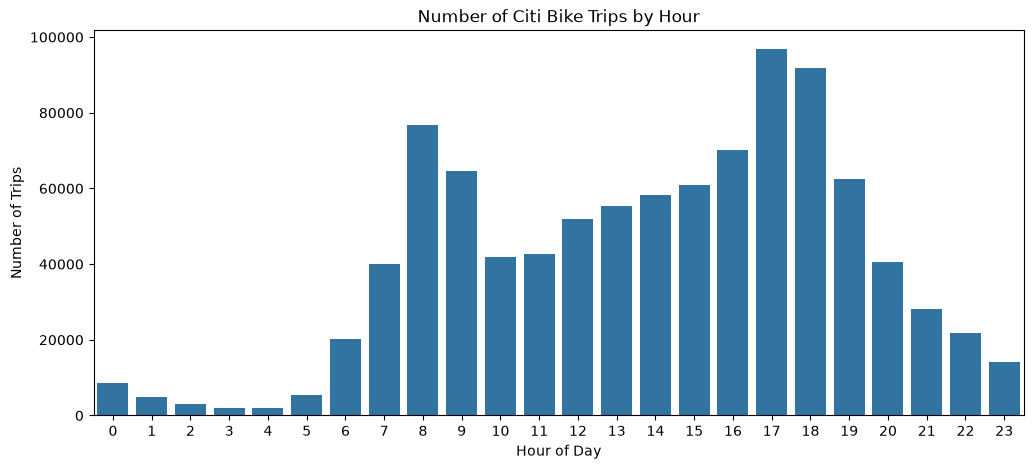

In [10]:
hourly_trips = df.groupby("Start_Hour").size()

plt.figure(figsize=(12, 5))

sns.barplot(
    x=hourly_trips.index,
    y=hourly_trips.values
)

plt.title("Number of Citi Bike Trips by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(24))

plt.show()

# Trips by Day of Week

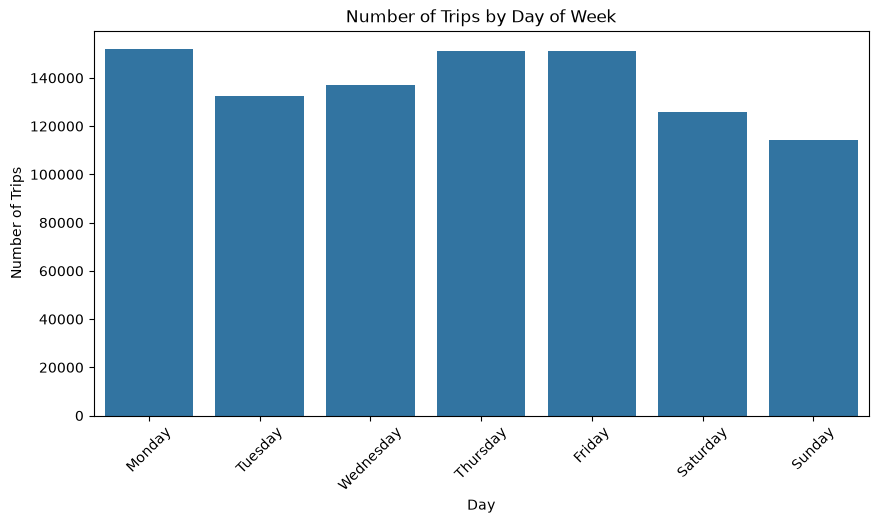

In [11]:
# Making the order of days

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_trips = (
    df["Day_of_Week"]
    .value_counts()
    .reindex(day_order)
)

# making the plot

plt.figure(figsize=(10, 5))

sns.barplot(
    x=daily_trips.index,
    y=daily_trips.values
)

plt.title("Number of Trips by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Trips")

plt.xticks(rotation=45)

plt.show()


# User Type Comparison

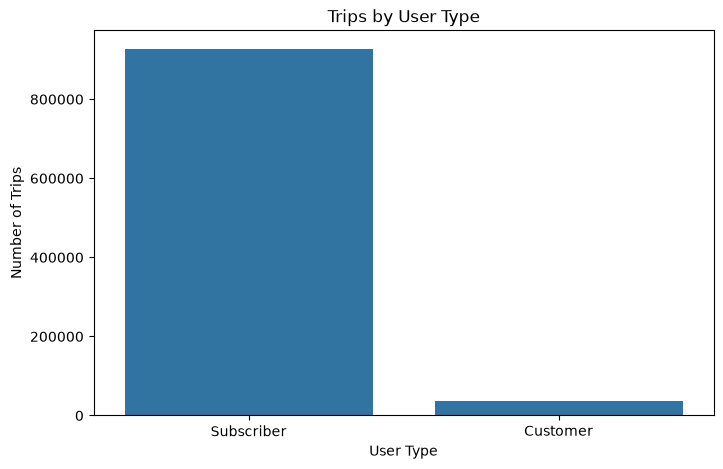

In [12]:
plt.figure(figsize = (8,5))
sns.countplot(data = df,
             x = "User_Type")
plt.title("Trips by User Type")
plt.xlabel("User Type")
plt.ylabel("Number of Trips")

plt.show()

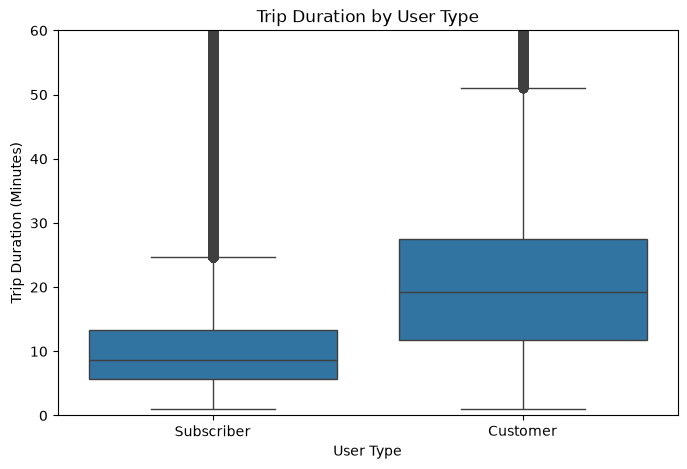

In [13]:
# Comparison of  trip duration between Subscriber and Customer

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="User_Type",
    y="Trip_Duration_Minutes"
)

plt.title("Trip Duration by User Type")
plt.xlabel("User Type")
plt.ylabel("Trip Duration (Minutes)")

plt.ylim(0, 60)

plt.show()

# Top 10 Start Stations

In [14]:
top_stations = (
    df["Start_Station_Name"]
    .value_counts()
    .head(10)
)
top_stations

Start_Station_Name
Lafayette St & E 8 St       11200
8 Ave & W 31 St             10248
W 21 St & 6 Ave              9777
E 17 St & Broadway           9324
8 Ave & W 33 St              8422
W 41 St & 8 Ave              7653
Broadway & E 14 St           7630
E 43 St & Vanderbilt Ave     7511
W 31 St & 7 Ave              7449
Broadway & E 22 St           7183
Name: count, dtype: int64

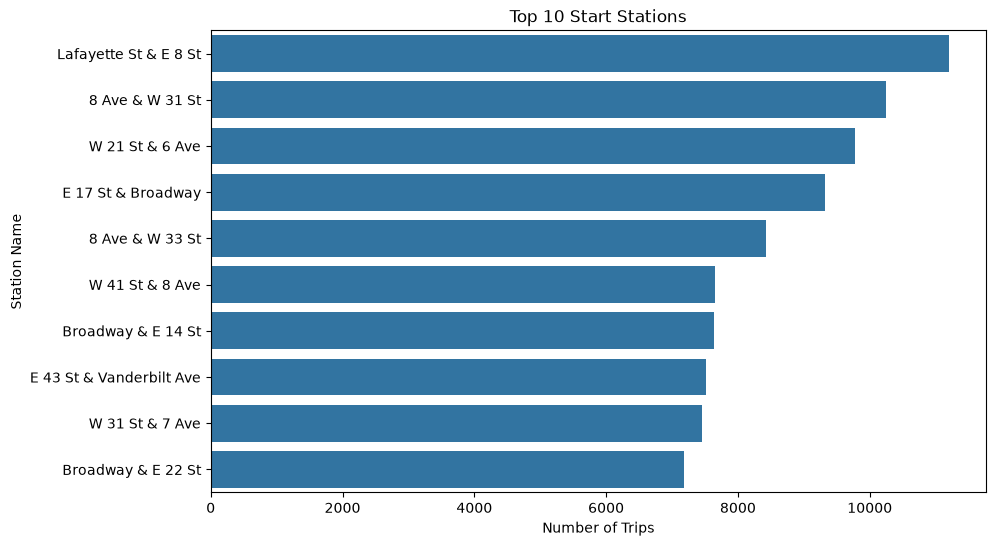

In [15]:
plt.figure(figsize=(10, 6))

sns.barplot(
    y=top_stations.index,
    x=top_stations.values
)

plt.title("Top 10 Start Stations")
plt.xlabel("Number of Trips")
plt.ylabel("Station Name")

plt.show()

# Top 10 end stations

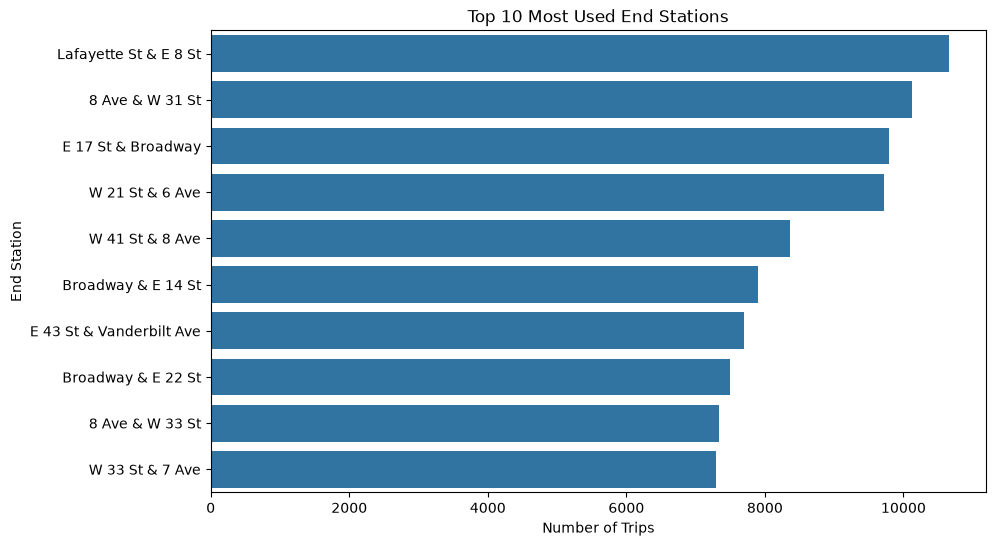

In [16]:
top_end = df["End_Station_Name"].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_end.values,
    y=top_end.index
)

plt.title("Top 10 Most Used End Stations")
plt.xlabel("Number of Trips")
plt.ylabel("End Station")
plt.show()

# Effect of Temperature on Number of Trips

In [17]:
# Creating the bins

df["Temperature_Bin"] = pd.cut(
    df["Temperature_2M (°C)"],
    bins=10
)
temperature_trips = (
    df.groupby("Temperature_Bin", observed=True)
    .size()
)

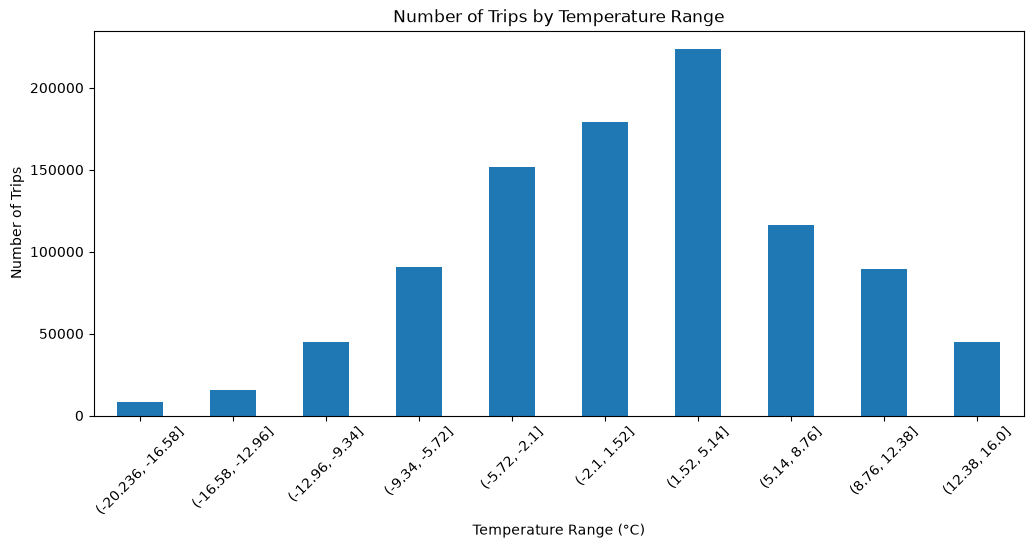

In [18]:
# mkaing the plot

plt.figure(figsize=(12, 5))

temperature_trips.plot(kind="bar")

plt.title("Number of Trips by Temperature Range")
plt.xlabel("Temperature Range (°C)")
plt.ylabel("Number of Trips")

plt.xticks(rotation=45)

plt.show()

# Effect of Precipitation on Trips

In [19]:
# creating the feature
df["Has_Rain"] = (
    df["Precipitation (Mm)"] > 0
)

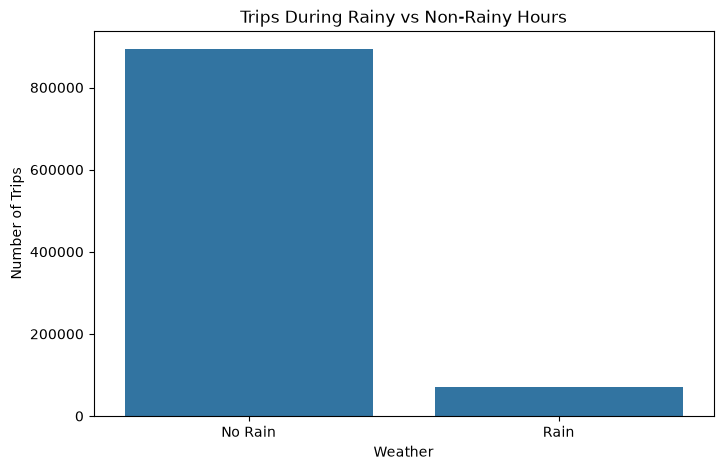

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Has_Rain"
)

plt.title("Trips During Rainy vs Non-Rainy Hours")
plt.xlabel("Weather")
plt.ylabel("Number of Trips")

plt.xticks(
    [0, 1],
    ["No Rain", "Rain"]
)

plt.show()

# Weekend vs Weekday Patterns

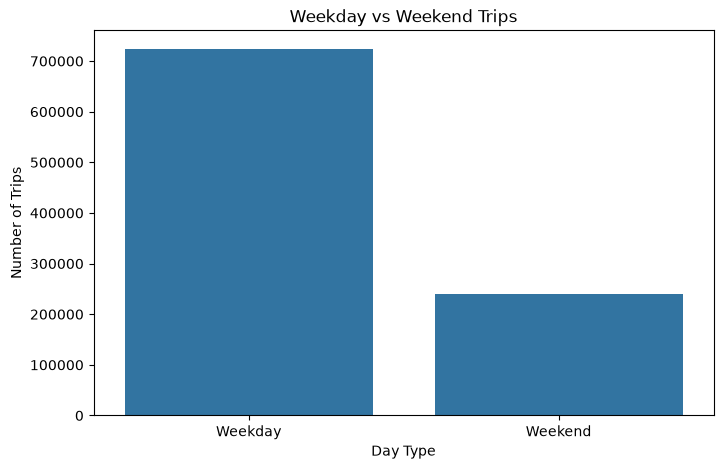

In [21]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Day_Type"
)

plt.title("Weekday vs Weekend Trips")
plt.xlabel("Day Type")
plt.ylabel("Number of Trips")

plt.show()

# Correlation heatmap

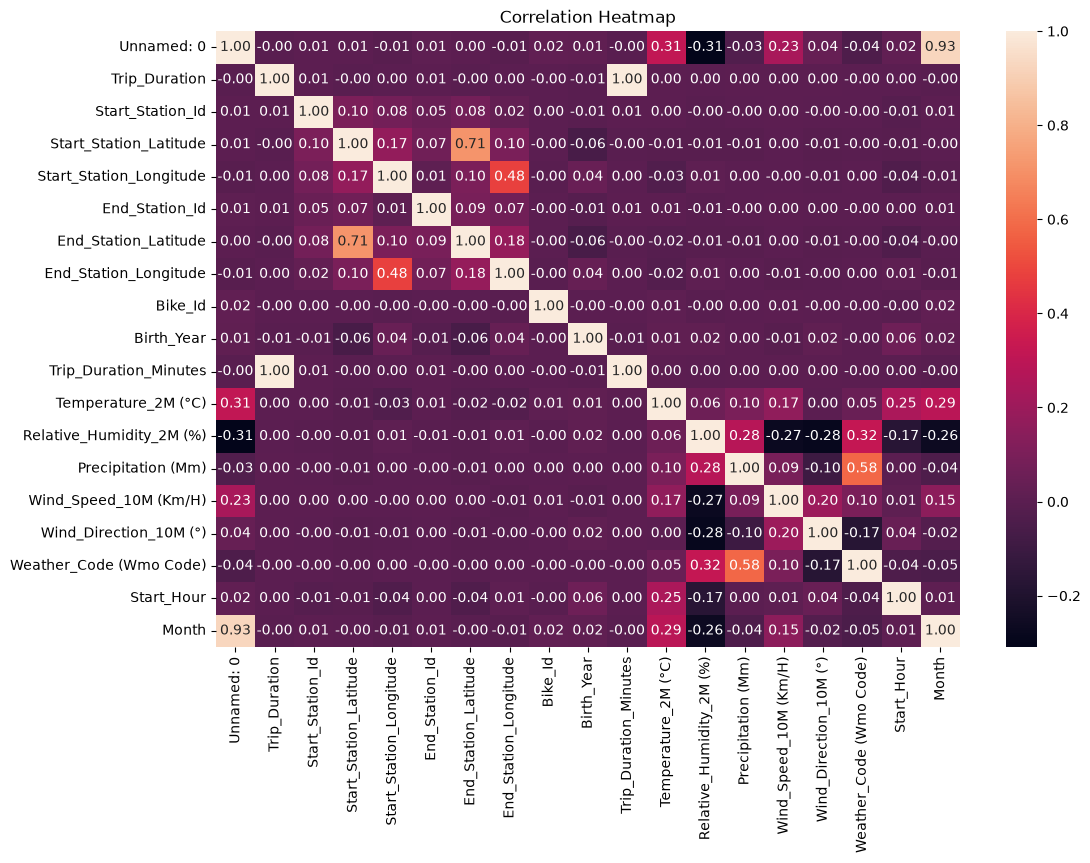

In [22]:
plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# Average trip Duration By Hour

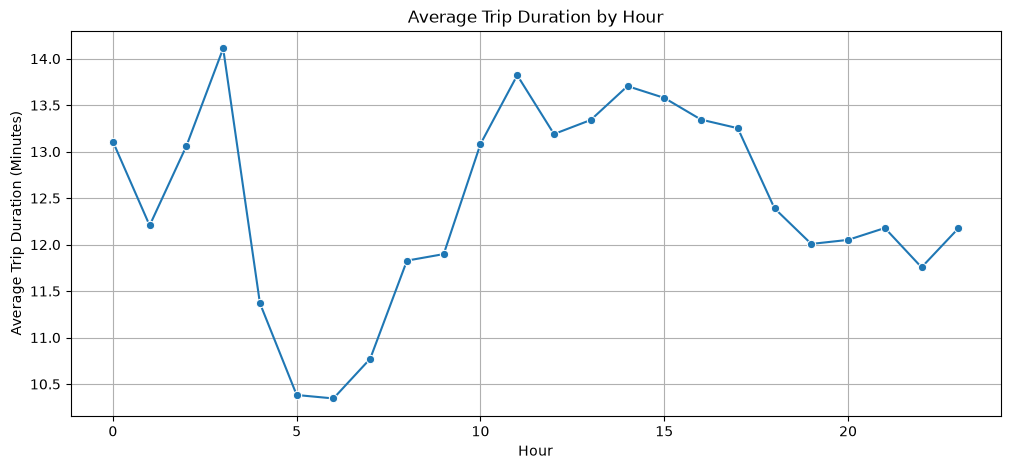

In [23]:
avg_duration_hour = (
    df.groupby("Start_Hour")["Trip_Duration_Minutes"]
      .mean()
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    x=avg_duration_hour.index,
    y=avg_duration_hour.values,
    marker="o"
)

plt.title("Average Trip Duration by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Trip Duration (Minutes)")
plt.grid()
plt.show()

In [25]:
df.to_csv("CitiBike_Final_Data.csv",index = True)
print("completed successfully")

completed successfully
